# MLP Training and Experiments for MAGIC Telescope

Training and evaluating neural network models on the MAGIC Gamma Telescope dataset using our custom numpy-based framework.

## 1. Setup and Data Loading

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
from src.preprocessing import load_magic_dataset, preprocess_data, create_batches
from src.utils import set_seed, print_model_summary

set_seed(42)

# Load data
X, y = load_magic_dataset()
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

# Preprocess
data = preprocess_data(X, y)
print(f"Train: {data['train']['X'].shape}, Val: {data['val']['X'].shape}, Test: {data['test']['X'].shape}")

Loading MAGIC Gamma Telescope dataset from UCI ML Repository...
✓ Dataset loaded: 19020 samples, 10 features
Dataset shape: X=(19020, 10), y=(19020,)
Class distribution: [ 6688 12332]
Train: (11412, 10), Val: (3804, 10), Test: (3804, 10)


## 2. Build Baseline Model

In [4]:
from src.model import Model
from src.layers import Linear
from src.activations import ReLU, Sigmoid, Tanh
from src.losses import BCELoss
from src.optimizers import Adam

# Build baseline model
model = Model()
model.add_module(Linear(10, 32), 'linear1')
model.add_module(ReLU(), 'relu1')
model.add_module(Linear(32, 16), 'linear2')
model.add_module(ReLU(), 'relu2')
model.add_module(Linear(16, 1), 'linear3')
model.add_module(Sigmoid(), 'sigmoid')

print_model_summary(model)


Model Architecture
linear1                        | Linear
                               | Params: 352 (W: (32, 10), b: (32, 1))
relu1                          | ReLU
linear2                        | Linear
                               | Params: 528 (W: (16, 32), b: (16, 1))
relu2                          | ReLU
linear3                        | Linear
                               | Params: 17 (W: (1, 16), b: (1, 1))
sigmoid                        | Sigmoid
Total trainable parameters: 897



## 3. Train Baseline Model

Epoch 1/100 - loss: 0.4430 - val_loss: 0.3806 - acc: 0.8338 - val_acc: 0.8318
Epoch 10/100 - loss: 0.3189 - val_loss: 0.3112 - acc: 0.8704 - val_acc: 0.8675
Epoch 20/100 - loss: 0.3043 - val_loss: 0.3036 - acc: 0.8762 - val_acc: 0.8722
Epoch 30/100 - loss: 0.2976 - val_loss: 0.2994 - acc: 0.8788 - val_acc: 0.8728
Epoch 40/100 - loss: 0.2926 - val_loss: 0.3036 - acc: 0.8807 - val_acc: 0.8699
Epoch 50/100 - loss: 0.2887 - val_loss: 0.2988 - acc: 0.8828 - val_acc: 0.8728
Epoch 60/100 - loss: 0.2843 - val_loss: 0.2952 - acc: 0.8849 - val_acc: 0.8767
Epoch 70/100 - loss: 0.2815 - val_loss: 0.2972 - acc: 0.8881 - val_acc: 0.8738
Early stopping at epoch 77

✓ Training complete!


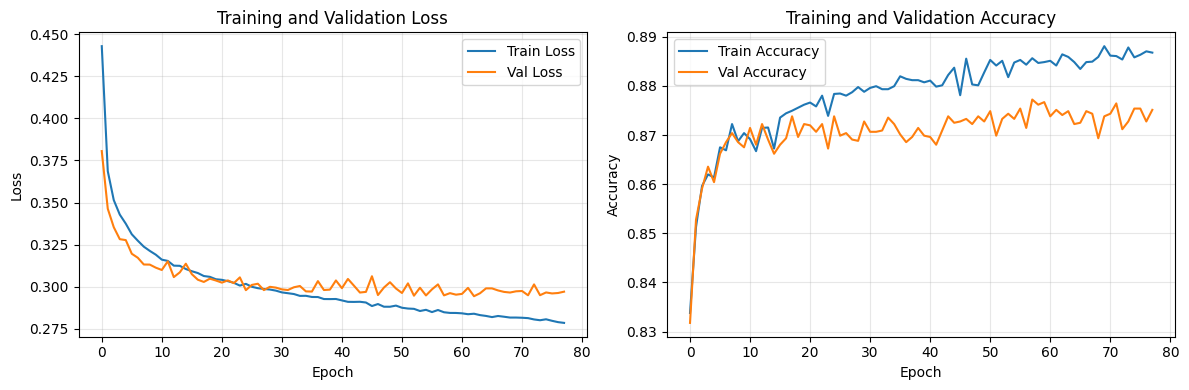

In [5]:
from src.trainer import Trainer
from src.visualization import plot_training_history

# Setup
loss_fn = BCELoss()
optimizer = Adam(lr=0.001)
trainer = Trainer(model, loss_fn, optimizer, batch_size=32)

# Train
history = trainer.fit(
    data['train']['X'], data['train']['y'],
    data['val']['X'], data['val']['y'],
    epochs=100,
    early_stopping=True,
    patience=15
)

# Plot
plot_training_history(history)
print("\n✓ Training complete!")

## 4. Evaluate on Test Set

In [6]:
# Evaluate
_, test_metrics = trainer.evaluate(data['test']['X'], data['test']['y'])

print("\nTest Set Metrics:")
print("="*40)
for metric, value in test_metrics.items():
    print(f"{metric:15s}: {value:.4f}")
print("="*40)


Test Set Metrics:
accuracy       : 0.8709
precision      : 0.8700
recall         : 0.9416
f1             : 0.9044


## 5. Visualizations

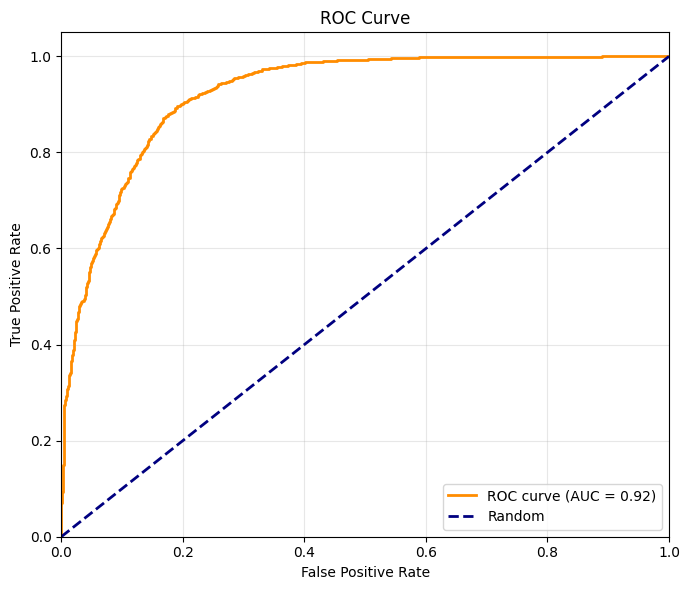

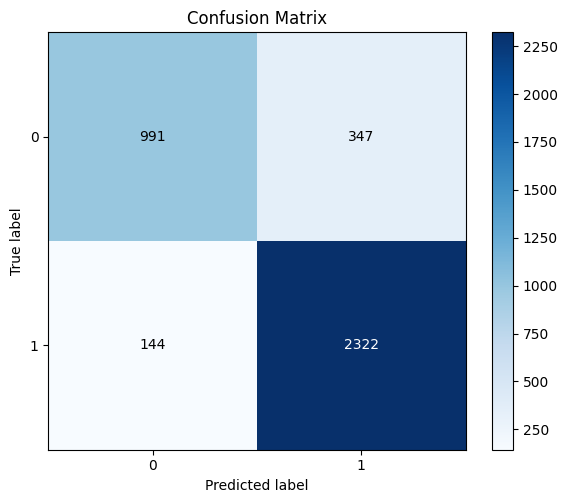

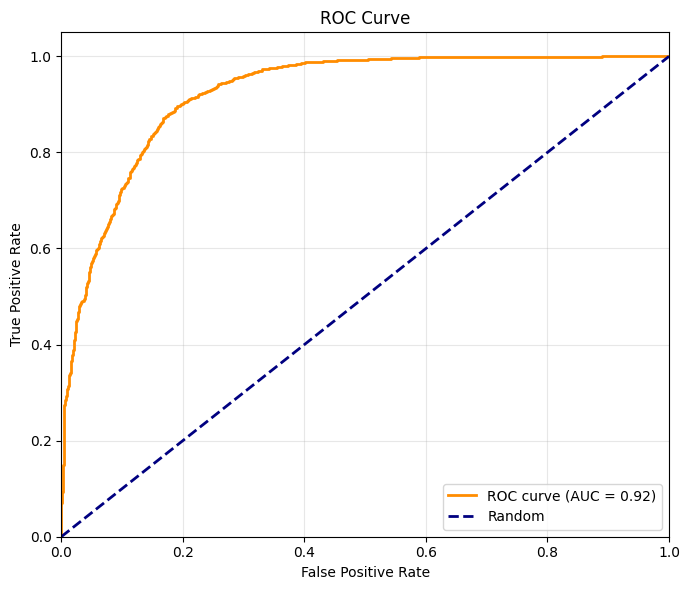

In [7]:
from src.visualization import plot_confusion_matrix, plot_roc_curve

# Predictions
y_test = data['test']['y']
y_proba = trainer.predict_proba(data['test']['X'])
y_pred = trainer.predict(data['test']['X'])

# Confusion matrix
plot_confusion_matrix(y_test, y_pred)

# ROC curve
plot_roc_curve(y_test, y_proba)

## 6. Multi-Experiment Tracking
Run a predefined set of experiments and save comparison results to `results/experiments.csv`.

In [ ]:
from src.experiments import default_experiment_configs, run_experiments

configs = default_experiment_configs()
results = run_experiments(
    data=data,
    configs=configs,
    results_csv="../results/experiments.csv",
    seed=42,

)

print("\nTop experiments by validation F1:")
for row in results[:3]:
    print(
        f"{row['experiment_name']:20s} | "
        f"val_f1={row['validation_f1']:.4f} | "
        f"test_f1={row['test_f1']:.4f}"
    )